In [1]:
!pip install mne
import numpy as np
import mne
import matplotlib.pyplot as plt
import scipy
import pandas as pd

In [ ]:
data_path = 'C:/Users/annma/Documents/IITP/emg_writing/data_8ch_EMG/export1_20Dec07.mat'
data = scipy.io.loadmat(data_path)
list(data.keys())

In [ ]:
data_emg = data['export_EMG']
data_x_y = np.squeeze([data[key] for key in list(data.keys())[4:6]]).T
print('data emg shape: ', data_emg.shape)
print('data x y shape: ', data_x_y.shape)

In [ ]:
data_target_common = np.array(data['export_Type']) - 1
data_on_paper = np.squeeze(data['export_OnPaper'])
data_trials = np.squeeze(data['export_Trial'])

In [ ]:
vis_index = 100000
plt.plot(data_trials[:vis_index])
plt.plot(data_on_paper[:vis_index])
plt.plot(data_target_common[:vis_index])
plt.legend(['single trials', 'is on paper', 'target digit'])

In [6]:
marks = [0]
counter = 1
for i in range(len(data_trials)-1):
    x0 = data_trials[i]
    x1 = data_trials[i+1]
    if x1!=x0:
        marks.append(counter)
    counter+=1
print(marks)

[0, 6516, 13141, 20469, 27969, 34624, 42031, 49046, 55624, 63141, 70485, 77564, 84752, 91767, 98595, 105611, 112672, 119781, 126750, 132562, 138905, 144686, 152046, 158202, 163889, 170575, 176809, 183747, 190232, 197216, 204498, 211170, 218123, 224983, 232077, 239499, 246390, 253546, 260813, 267985, 275078, 282000, 288750, 296093, 303374, 310310, 317544, 324405, 331155, 337936, 344576, 349403, 355106, 360059, 364465, 369621, 374246, 378823, 383385, 388824, 394480, 399449, 404511, 409464, 415074, 420449, 425480, 430902, 436542, 442135, 447088, 452650, 458087, 463415, 468086, 473805, 479400, 484932, 490477, 495930, 501509, 506946, 512463, 518010, 522868, 528008, 533571, 538712, 543993, 548353, 552617, 556554, 560818, 566380, 571755, 576943, 581036, 586379, 591832, 597363, 602927, 608004, 614504, 620848, 627363, 633817, 640128, 646659, 653159, 659596, 666097, 672582, 679161, 685521, 691989, 698473, 704817, 711037, 717270, 723552, 730006, 736444, 743085, 749693, 756100, 762647, 769225, 775

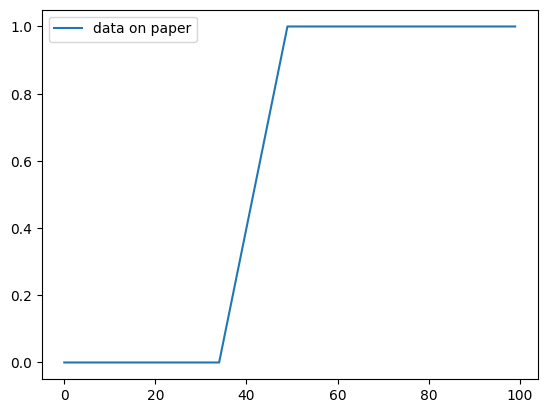

In [7]:
plt.plot(data_on_paper[1950:2050])
plt.legend(['data on paper'])

In [8]:
marks_on_paper_draft = []
counter = 0
for i in range(len(data_on_paper)-1):
    x0 = data_on_paper[i]
    x1 = data_on_paper[i+1]
    if x0==0 and x1!=0:
        new_mark_0 = counter
        marks_on_paper_draft.append(new_mark_0)
    if 0<x0<1 and x1==1:
        new_mark_1 = counter
        marks_on_paper_draft.append(new_mark_1)
    counter+=1
print(marks_on_paper_draft)
marks_on_paper = [0]
for i in range(0, len(marks_on_paper_draft)-1, 2):
    marks_on_paper.append(int(np.mean([marks_on_paper_draft[i], marks_on_paper_draft[i+1]])))

[1984, 1999, 8499, 8515, 15125, 15140, 22452, 22468, 29951, 29968, 36609, 36623, 44014, 44030, 50608, 50623, 57608, 57623, 65125, 65140, 72469, 72484, 79548, 79563, 86735, 86751, 93532, 93547, 100579, 100594, 107593, 107610, 114655, 114671, 121765, 121780, 127701, 127717, 133857, 133872, 139654, 139669, 146670, 146685, 153434, 153451, 158888, 158904, 165496, 165512, 172058, 172073, 178793, 178808, 185199, 185214, 192215, 192231, 199199, 199215, 206482, 206497, 213154, 213169, 220012, 220027, 226966, 226982, 234060, 234076, 241482, 241498, 248373, 248389, 255531, 255545, 262797, 262812, 269952, 269968, 277061, 277077, 283983, 283999, 290733, 290749, 298076, 298092, 305231, 305247, 312293, 312309, 319529, 319543, 326388, 326404, 333137, 333154, 339918, 339935, 345855, 345871, 351386, 351402, 356449, 356465, 360808, 360824, 365870, 365885, 370759, 370776, 375260, 375275, 379900, 379915, 385368, 385384, 390807, 390823, 395713, 395728, 400837, 400854, 405823, 405838, 411448, 411463, 416806,

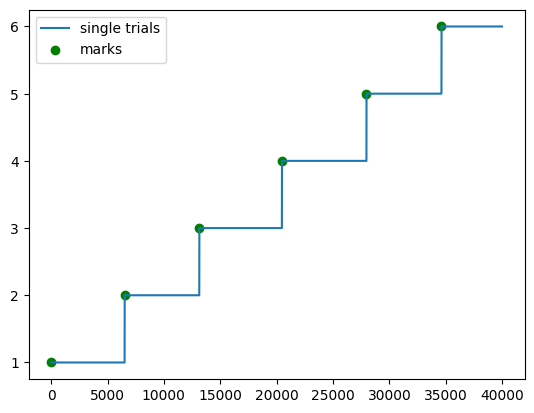

In [9]:
vis_index = 40000
plt.plot(data_trials[:vis_index])
plt.scatter(marks[:data_trials[vis_index]], data_trials[marks[:data_trials[vis_index]]], c='g')
plt.legend(['single trials', 'marks'])

In [10]:
def get_data_trials(data, marks):
    data_trials = []
    for i in range(len(marks)-1):
        data_trials.append(data[marks[i]:marks[i+1],:])
    return data_trials

data_emg_trials = get_data_trials(data_emg, marks)
data_x_y_trials = get_data_trials(data_x_y, marks)
print('n trials orig:', data_trials[-1], '\n',
      'n trials emg:', len(data_emg_trials), '\n',
      'n trials x y:', len(data_x_y_trials), '\n',
      )

data_target_common_trials = get_data_trials(data_target_common, marks)
print('n trials targets:', len(data_target_common_trials), '\n')

data_targets = [int(np.mean(target_trial)) for target_trial in data_target_common_trials]
print('n targets:', len(data_targets), '\n',
      'targets:', data_targets, '\n',)

data_on_paper_trials = get_data_trials(np.expand_dims(data_on_paper,-1), marks_on_paper)
print('n trials on paper:', len(data_on_paper_trials))

n trials orig: 491 
 n trials emg: 490 
 n trials x y: 490 

n trials targets: 490 

n targets: 490 
 targets: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 

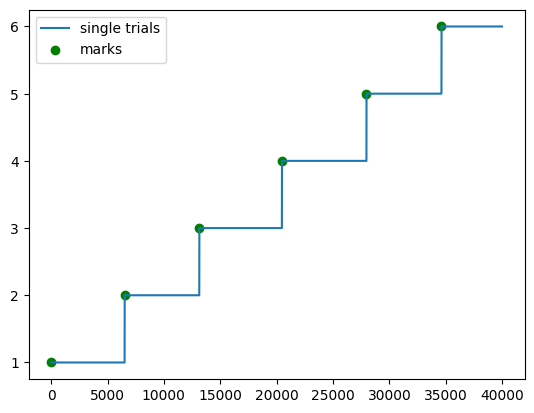

In [11]:
vis_index = 40000
plt.plot(data_trials[:vis_index])
plt.scatter(marks[:data_trials[vis_index]], data_trials[marks[:data_trials[vis_index]]], c='g')
plt.legend(['single trials', 'marks'])

3937 9718 6092


Text(3500, 30, 'min: 3937; max: 9718; mean: 6092')

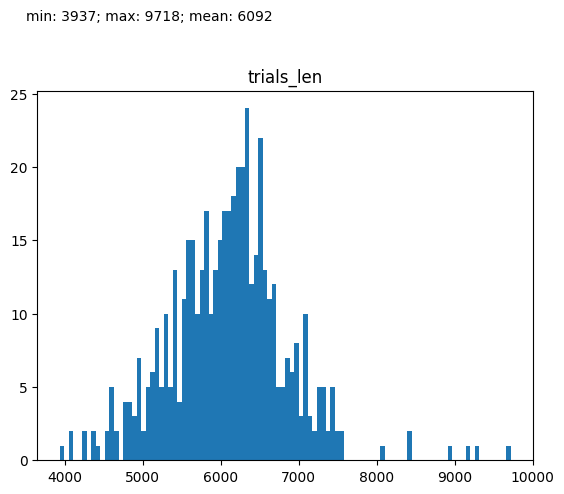

In [12]:
trials_len = np.array([len(trial) for trial in data_emg_trials])
print(np.min(trials_len),
      np.max(trials_len),
      round(np.mean(trials_len)))
plt.hist(trials_len, bins=100)
plt.title('trials_len')
plt.text(3500,30,f'min: {np.min(trials_len)}; max: {np.max(trials_len)}; mean: {round(np.mean(trials_len))}')

1063 7517 4285


Text(880, 45, 'min: 1063; max: 7517; mean: 4285')

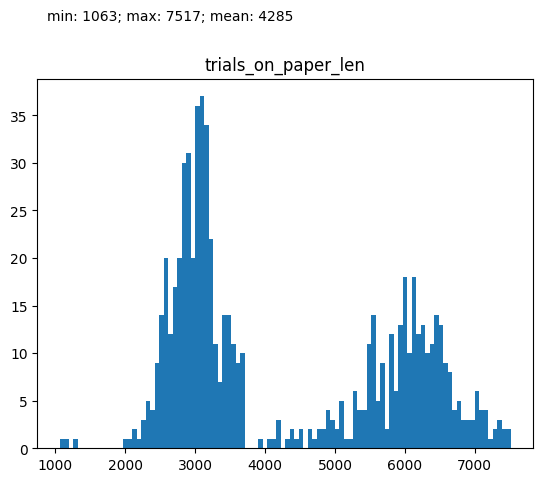

In [13]:
trials_on_paper_len = np.array([len(trial) for trial in data_on_paper_trials])
print(np.min(trials_on_paper_len),
      np.max(trials_on_paper_len),
      round(np.mean(trials_on_paper_len)))
plt.hist(trials_on_paper_len, bins=100)
plt.title('trials_on_paper_len')
plt.text(880,45,f'min: {np.min(trials_on_paper_len)}; max: {np.max(trials_on_paper_len)}; mean: {round(np.mean(trials_on_paper_len))}')

In [14]:
%matplotlib qt5 

In [14]:
def get_data_trials_eq(data, marks, half_window_size=2800):
    data_trials_eq = []
    for i in range(len(marks)-1):
        mark_mean = round(np.mean([marks[i], marks[i+1]]))
        mark_0 = mark_mean - half_window_size
        mark_1 = mark_mean + half_window_size
        data_trials_eq.append(data[mark_0:mark_1,:])

    # print(len(data_trials_eq))
    # print(data_trials_eq[20].shape)
    return np.array(data_trials_eq)

In [17]:
# data_x_y_trials_eq = get_data_trials_eq(data_x_y, marks, half_window_size=2800)
# data_emg_trials_eq = get_data_trials_eq(data_emg, marks, half_window_size=2800)
# data_on_paper_trials_eq = np.squeeze(get_data_trials_eq(np.expand_dims(data_on_paper, -1), marks, half_window_size=2800))
# print('x y trials eq shape: ', data_x_y_trials_eq.shape)
# print('emg trials eq shape: ', data_emg_trials_eq.shape)
# print('on paper trials eq shape: ', data_on_paper_trials_eq.shape)

In [18]:
# i_n = 9
# j_n = 9

# for k in range(8):

#     c = i_n*j_n*k

#     fig = plt.figure(figsize=(100,100))
#     for i in range(i_n):
#         for j in range(j_n):
#             try:
#                 plt.subplot2grid((i_n,j_n), (i, j), rowspan=1, colspan=1, fig=fig)
#                 plt.plot(data_on_paper_trials_eq[c])
#             except: pass
#             plt.legend([c])
#             c+=1

In [19]:
# i_n = 9
# j_n = 9
# c = i_n*j_n*6
# fig = plt.figure(figsize=(100,100))
# for i in range(i_n):
#     for j in range(j_n):
#         plt.subplot2grid((i_n,j_n), (i, j), rowspan=1, colspan=1, fig=fig)
#         plt.scatter(data_x_y_trials[c][:,0], data_x_y_trials[c][:,1], marker=1, linewidths=0.4)
#         c+=1

### get datasets with all data

In [20]:
from pathlib import Path
from os import walk

In [21]:
data_path_all = Path(r"D:\annma\emg_writing\data_8ch_EMG").as_posix()
filenames = next(walk(data_path_all), (None, None, []))[2]
filenames

['export1_13Nov07.mat',
 'export1_15Jan08.mat',
 'export1_15Nov07.mat',
 'export1_19Dec07.mat',
 'export1_20Dec07.mat',
 'export1_21Dec07.mat',
 'export1_24Jan08.mat',
 'export1_2Jan08.mat',
 'export1_30Nov07.mat',
 'export1_3Jan08.mat',
 'export1_7Jan08.mat']

In [22]:
# sub=1
# i_n = 4
# j_n = 3
# fig = plt.figure(figsize=(30,30))

# for i in range(i_n):
#       for j in range(j_n):
#             try:
#                   data = scipy.io.loadmat(data_path_all+filenames[sub-1])
#                   data_emg = data['export_EMG']
#                   data_trials = np.squeeze(data['export_Trial'])

#                   marks = [0]
#                   counter = 1
#                   for k in range(len(data_trials)-1):
#                         x0 = data_trials[k]
#                         x1 = data_trials[k+1]
#                         if x1!=x0:
#                               marks.append(counter)
#                         counter+=1

#                   data_emg_trials = get_data_trials(data_emg, marks)
                  
#                   trials_len = np.array([len(trial) for trial in data_emg_trials])
#                   print(np.min(trials_len),
#                         np.max(trials_len),
#                         round(np.mean(trials_len)))
#                   plt.subplot2grid((i_n,j_n), (i, j), fig=fig)
#                   plt.hist(trials_len, bins=100)
#                   plt.title(f'trials_len s{sub}')
#                   plt.legend([f'min: {np.min(trials_len)}; max: {np.max(trials_len)}; mean: {round(np.mean(trials_len))}'])
#             except: pass
#             sub+=1


In [23]:
def get_emg_dataset(data_path):

    data = scipy.io.loadmat(data_path)

    data_emg = data['export_EMG']
    print('data emg shape: ', data_emg.shape)
    
    # data_x_y = np.squeeze([data[key] for key in list(data.keys())[4:6]])
    # print('data x y shape: ', data_x_y.shape)
    
    data_target_common = np.array(data['export_Type']) - 1
    # data_on_paper = np.squeeze(data['export_OnPaper'])
    data_trials = np.squeeze(data['export_Trial'])
    print('n trials:', data_trials[-1])

    marks = [0]
    counter = 1
    for i in range(len(data_trials)-1):
        x0 = data_trials[i]
        x1 = data_trials[i+1]
        if x1!=x0:
            marks.append(counter)
        counter+=1
    # print(marks)

    # marks_on_paper_draft = []
    # counter = 0
    # for i in range(len(data_on_paper)-1):
    #     x0 = data_on_paper[i]
    #     x1 = data_on_paper[i+1]
    #     if x0==0 and x1!=0:
    #         new_mark_0 = counter
    #         marks_on_paper_draft.append(new_mark_0)
    #     if 0<x0<1 and x1==1:
    #         new_mark_1 = counter
    #         marks_on_paper_draft.append(new_mark_1)
    #     counter+=1
    # print(marks_on_paper_draft)
    # marks_on_paper = [0]
    # for i in range(0, len(marks_on_paper_draft), 2):
    #     marks_on_paper.append(int(np.mean([marks_on_paper_draft[i], marks_on_paper_draft[i+1]])))

    # data_on_paper_trials = get_data_trials(np.expand_dims(data_on_paper,-1), marks_on_paper)
    # print('n trials on paper:', len(data_on_paper_trials))

    # data_emg_trials = get_data_trials(data_emg, marks)
    # # data_x_y_trials = get_data_trials(data_x_y, marks)
    # print(
    #     'n trials emg:', len(data_emg_trials), '\n',
    #     # 'n trials x y:', len(data_x_y_trials), '\n',
    #     )

    # data_target_common_trials = get_data_trials(data_target_common, marks)
    # # print('n trials targets:', len(data_target_common_trials), '\n')

    data_emg_trials_eq = get_data_trials_eq(data_emg, marks, half_window_size=1400)
    data_target_common_trials = get_data_trials_eq(data_target_common, marks, half_window_size=1400)
    # data_x_y_trials_eq = get_data_trials_eq(data_x_y, marks, half_window_size=2800)
    # data_on_paper_trials_eq = np.squeeze(get_data_trials_eq(np.expand_dims(data_on_paper, -1), marks, half_window_size=2800))
    print('emg trials eq shape: ', data_emg_trials_eq.shape)
    # print('x y trials eq shape: ', data_x_y_trials_eq.shape)
    # print('on paper trials eq shape: ', data_on_paper_trials_eq.shape)

    data_targets = [int(np.mean(target_trial)) for target_trial in data_target_common_trials]
    print('n targets:', len(data_targets), '\n',
        # 'targets:', data_targets
        )
    return [data_emg_trials_eq, data_targets]

In [24]:
data_path_all

'D:/annma/emg_writing/data_8ch_EMG'

In [25]:
datasets_all = [get_emg_dataset(data_path_all+'/'+data_path) for data_path in filenames]

data emg shape:  (3234809, 8)
n trials: 499
emg trials eq shape:  (498, 2800, 8)
n targets: 498 

data emg shape:  (3799409, 8)
n trials: 550
emg trials eq shape:  (549, 2800, 8)
n targets: 549 

data emg shape:  (3350592, 8)
n trials: 450
emg trials eq shape:  (449, 2800, 8)
n targets: 449 

data emg shape:  (3228613, 8)
n trials: 477
emg trials eq shape:  (476, 2800, 8)
n targets: 476 

data emg shape:  (2990369, 8)
n trials: 491
emg trials eq shape:  (490, 2800, 8)
n targets: 490 

data emg shape:  (2952945, 8)
n trials: 492
emg trials eq shape:  (491, 2800, 8)
n targets: 491 

data emg shape:  (4017936, 8)
n trials: 555
emg trials eq shape:  (554, 2800, 8)
n targets: 554 

data emg shape:  (3485025, 8)
n trials: 491
emg trials eq shape:  (490, 2800, 8)
n targets: 490 

data emg shape:  (2707637, 8)
n trials: 469
emg trials eq shape:  (468, 2800, 8)
n targets: 468 

data emg shape:  (3589231, 8)
n trials: 518
emg trials eq shape:  (517, 2800, 8)
n targets: 517 

data emg shape:  (38

In [6]:
import numpy as np

In [11]:
n_trials_str = list('498 549 449 476 490 491 554 490 468 517 548'.split(' '))
n_trials = [int(n) for n in n_trials_str]
print(n_trials)
sub_marks = np.concatenate([np.repeat(i, n) for i, n  in zip(range(len(n_trials)), n_trials)])
print(len(sub_marks))
np.save('sub_marks.npy', sub_marks)

[498, 549, 449, 476, 490, 491, 554, 490, 468, 517, 548]
5530


In [26]:
for i in range(len(datasets_all)):
    print(len(datasets_all[i][0]), len(datasets_all[i][1]))

498 498
549 549
449 449
476 476
490 490
491 491
554 554
490 490
468 468
517 517
548 548


In [24]:
# import pickle
# with open(data_path_all+'data_emg_targets_all.pickle', 'wb') as handle:
#     pickle.dump(datasets_all, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [27]:
data_emg_all = np.concatenate([data_sub[0] for data_sub in datasets_all], axis=0)
data_target_all = np.concatenate([data_sub[1] for data_sub in datasets_all], axis=0)

In [28]:
print(data_emg_all.shape)
print(data_target_all.shape)

(5530, 2800, 8)
(5530,)


In [30]:
# scipy.io.savemat('/dataset.mat', {'data': data_emg_all, 'label': data_target_all})